In [8]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
%load_ext autoreload
%autoreload 2
from utils import * # relative import
from scipy.io import loadmat
plt.rcParams['image.origin'] = 'lower'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
mission_df = pd.read_csv('/Users/mleclair/Dropbox/phd/code/dunex/drifters/DUNEXMainExp/analysis/../microSWIFT_data/mission_df.csv')
Tp = mission_df[(mission_df['mission number'] == 32)]['Tm [s]'].item()
print(f'{Tp=:.2f}s')

Tp=6.46s


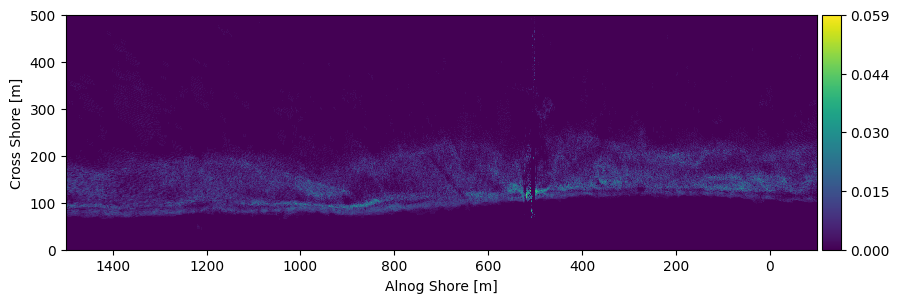

In [74]:
argus = xr.load_dataarray('qb_products/mission_32_argus_breakers.nc')
xs, ys = np.meshgrid(np.linspace(0, 500, 500), np.flip(np.linspace(-100, 1500, 1600)))

argus_breakers_per_tp = argus.sum('time') / ((argus.time.max().item()-argus.time.min().item()) / 1e9) / Tp
fig, ax = plt.subplots(figsize=(10, 10))
plot_frf_image(argus_breakers_per_tp, ax=ax, transpose=True)



In [75]:
def create_model_grid():
    x_cgrid_size = 1 # units are meters
    y_cgrid_size = 1 # units are meters
    x_cgrid_min = 50
    x_cgrid_max = 950
    y_cgrid_min = 0
    y_cgrid_max = 1000

    # Define number of points based on grid size
    num_x_points = int((x_cgrid_max - x_cgrid_min) / x_cgrid_size)+1
    print(num_x_points)
    num_y_points = int((y_cgrid_max - y_cgrid_min) / y_cgrid_size)+1
    print(num_y_points)

    # Create mesh grid
    x_cgrid, y_cgrid = np.meshgrid(np.linspace(x_cgrid_min, x_cgrid_max, num_x_points, dtype='int'),
                                   np.linspace(y_cgrid_min, y_cgrid_max, num_y_points, dtype='int'))

    return x_cgrid, y_cgrid

model_grid = create_model_grid()

901
1001


(-100.0, 1500.0)

/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/matplotlib/colors.py:1370: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


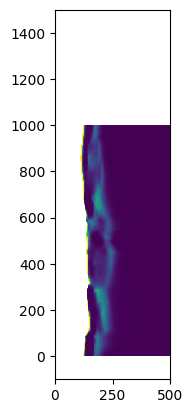

In [76]:
swan_only_qb = loadmat('qb_products/qb.mat')['Qb_20000101_020000']
swan_only_depth = loadmat('qb_products/depth.mat')['Depth_20000101_000000']
fig, ax = plt.subplots()
ax.pcolormesh(*model_grid, swan_only_qb)
xs = np.linspace(0, 500, 501, dtype='int')
ys = np.linspace(-100, 1500, 1601, dtype='int')

ax.set_aspect('equal')
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())

# Removing any white space
ax.set_adjustable('box')
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())

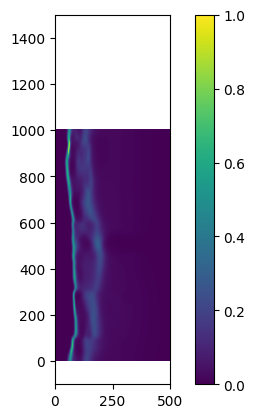

In [77]:
analytical_qb = xr.load_dataset('qb_products/mission_32_analytical_qb.nc')
fig, ax = plt.subplots()
im = ax.imshow(analytical_qb.qb)

xs = np.linspace(0, 500, 501, dtype='int')
ys = np.linspace(-100, 1500, 1601, dtype='int')

ax.set_aspect('equal')
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())

# Removing any white space
ax.set_adjustable('box')
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(ys.min(), ys.max())
plt.colorbar(im, ax=ax)

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_49213/1374395436.py:2: RuntimeWarning: invalid value encountered in cast
  reindexed_swan_qb[model_grid[1]+100, model_grid[0]-30] = swan_only_qb


Text(0.5, 1.0, 'SWAN (Red) - ARGUS (Blue)')

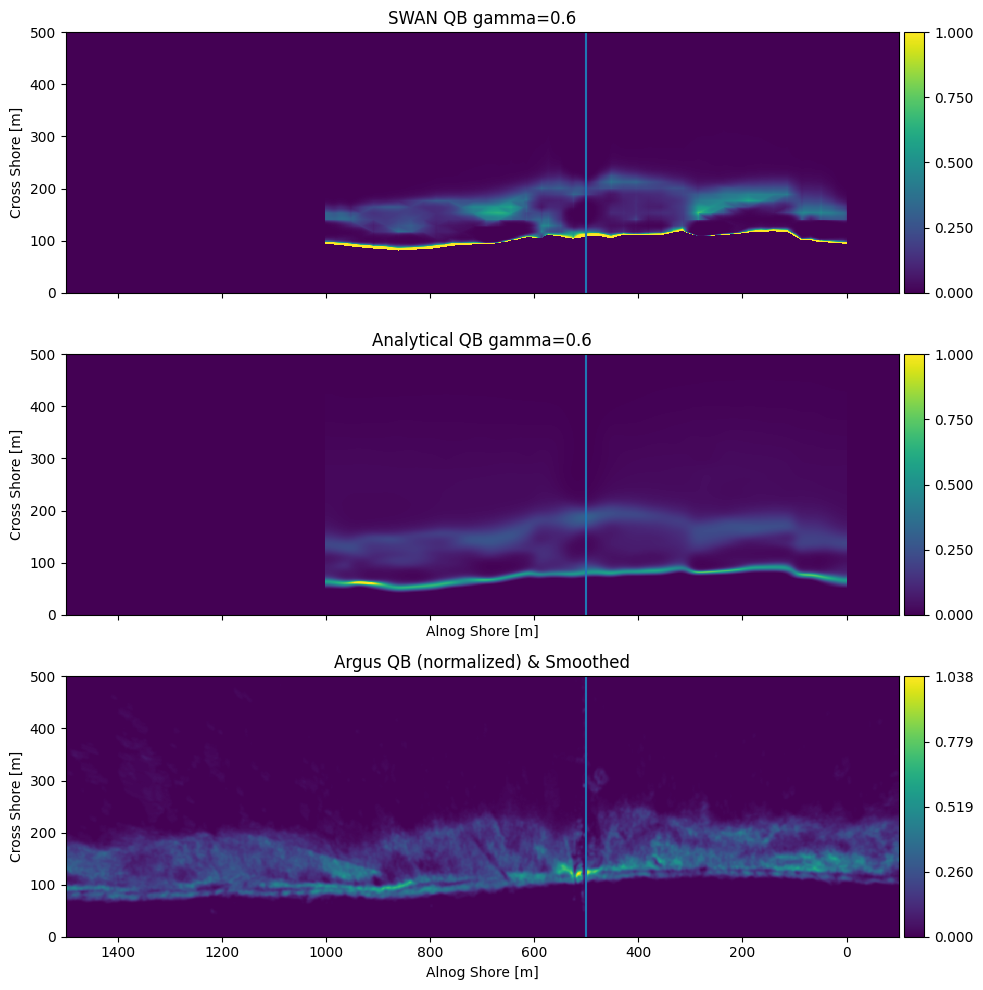

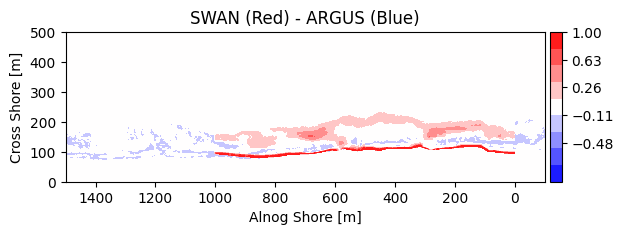

In [90]:
reindexed_swan_qb = np.zeros((1600, 1600))
reindexed_swan_qb[model_grid[1]+100, model_grid[0]-30] = swan_only_qb
reindexed_swan_qb[np.isnan(reindexed_swan_qb)] = 0
reindexed_swan_qb = reindexed_swan_qb[:1600, :500]
reindexed_swan_qb = np.flip(reindexed_swan_qb, 0)

reindexed_ana_qb = np.zeros((1600, 1600))
reindexed_ana_qb[model_grid[1]+100, model_grid[0]-50] = analytical_qb.qb
reindexed_ana_qb[np.isnan(reindexed_ana_qb)] = 0
reindexed_ana_qb = reindexed_ana_qb[:1600, :500]
reindexed_ana_qb = np.flip(reindexed_ana_qb, 0)

###
fig, axs = plt.subplots(3, 1, figsize=(30, 10), sharex=True)
plot_frf_image(reindexed_swan_qb, axs[0], transpose=True)
axs[0].axvline(500)
axs[0].set_xlabel('')
axs[1].set_xlabel('')
axs[0].set_title('SWAN QB gamma=0.6')

###
plot_frf_image(reindexed_ana_qb, axs[1], transpose=True)
axs[1].axvline(500)
axs[1].set_title(f'Analytical QB gamma={analytical_qb.attrs['gamma']}')

###
# plot_frf_image(scipy.ndimage.gaussian_filter(argus_breakers_per_tp, 2) * 2, axs[2], transpose=True)
plot_frf_image(
    scipy.ndimage.gaussian_filter(argus_breakers_per_tp/argus_breakers_per_tp.max(), 2) * 2,
    axs[2], transpose=True)
axs[2].axvline(500)
axs[2].set_title('Argus QB (normalized) & Smoothed')
plt.tight_layout()

###
fig, ax = plt.subplots()
im = plot_frf_image(reindexed_swan_qb - 1*scipy.ndimage.gaussian_filter(argus_breakers_per_tp/argus_breakers_per_tp.max(), 1), ax, transpose=True, levels=np.linspace(-1, 1, 10))
im.set_clim(vmin=-1, vmax=1)
im.set_cmap('bwr')
ax.set_title('SWAN (Red) - ARGUS (Blue)')

(-0.05, 1.05, -0.05, 1.05)

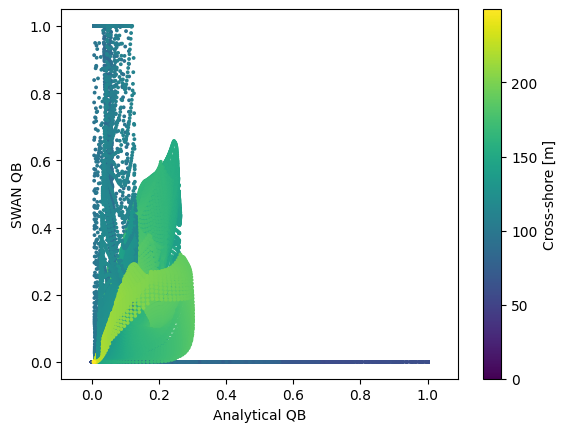

In [56]:
plt.scatter(reindexed_ana_qb[:1000, :250].flatten(), reindexed_swan_qb[:1000, :250].flatten(), c=xs[:1000, :250].flatten(), s=3)
plt.colorbar(label='Cross-shore [m]')
plt.xlabel('Analytical QB')
plt.ylabel('SWAN QB')
plt.axis('equal')

(-0.04979056568220947, 1.0456018793263988, -0.05, 1.05)

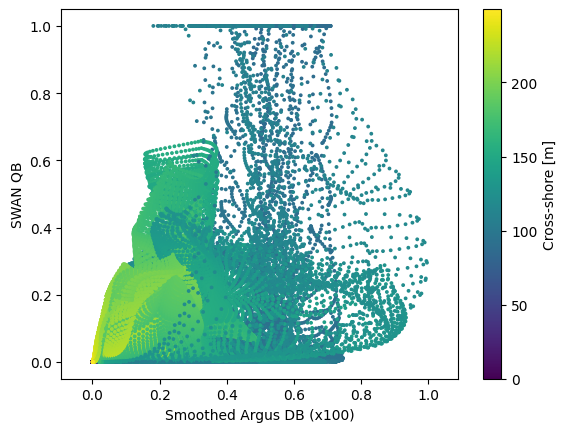

In [57]:
plt.scatter(
    scipy.ndimage.gaussian_filter(argus_breakers_per_tp[:1000, :250].values, 5).flatten()*100, reindexed_swan_qb[:1000, :250].flatten(), c=xs[:1000, :250].flatten(), s=3)
plt.colorbar(label='Cross-shore [m]')
plt.xlabel('Smoothed Argus DB (x100)')
plt.ylabel('SWAN QB')
plt.axis('equal')

(-0.04979056568220947, 1.0456018793263988, -0.05, 1.05)

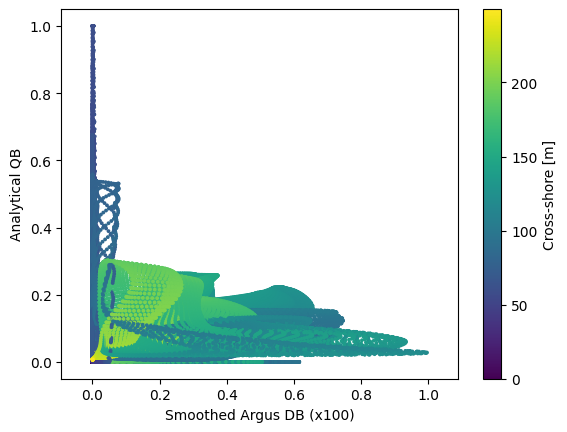

In [66]:
plt.scatter(
    scipy.ndimage.gaussian_filter(argus_breakers_per_tp[:1000, :250].values, 5).flatten()*100, reindexed_ana_qb[:1000, :250].flatten(), c=xs[:1000, :250].flatten(), s=3)
plt.colorbar(label='Cross-shore [m]')
plt.xlabel('Smoothed Argus DB (x100)')
plt.ylabel('Analytical QB')
plt.axis('equal')